# Pole shape — data sanity check

Run this notebook from the **repository root** (so `data/images` resolves). In VS Code/Cursor: open the folder `pole-shape-classifer`, then run cells. Select the project interpreter: `.venv/bin/python`.

In [46]:
%matplotlib inline

from pathlib import Path

import keras
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from keras import layers
from keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

ROOT = Path.cwd()
IMAGE_DIR = ROOT / "data" / "images"
if not IMAGE_DIR.is_dir():
    raise FileNotFoundError(
        f"Missing {IMAGE_DIR}. cd to the repo root or fix IMAGE_DIR."
    )

In [43]:
# Split the data into train, val and test
batch_size = 32
seed = 1337
# Load 80% of the data for training
full_ds = keras.utils.image_dataset_from_directory(
    IMAGE_DIR,
    seed=seed,
    shuffle=True,
    image_size=(224, 224),
    batch_size=None
)

# Split into 80% train and 20% temp
train_ds, temp_ds = tf.keras.utils.split_dataset(full_ds, left_size=0.8, shuffle=True, seed=seed)

# Split the 20% temp into 10% val and 10% test (half of the remainder)
val_ds, test_ds = tf.keras.utils.split_dataset(temp_ds, left_size=0.5, shuffle=True, seed=seed)

# Batch AFTER splitting
train_ds = train_ds.batch(batch_size)
val_ds   = val_ds.batch(batch_size)
test_ds  = test_ds.batch(batch_size)


Found 1903 files belonging to 2 classes.


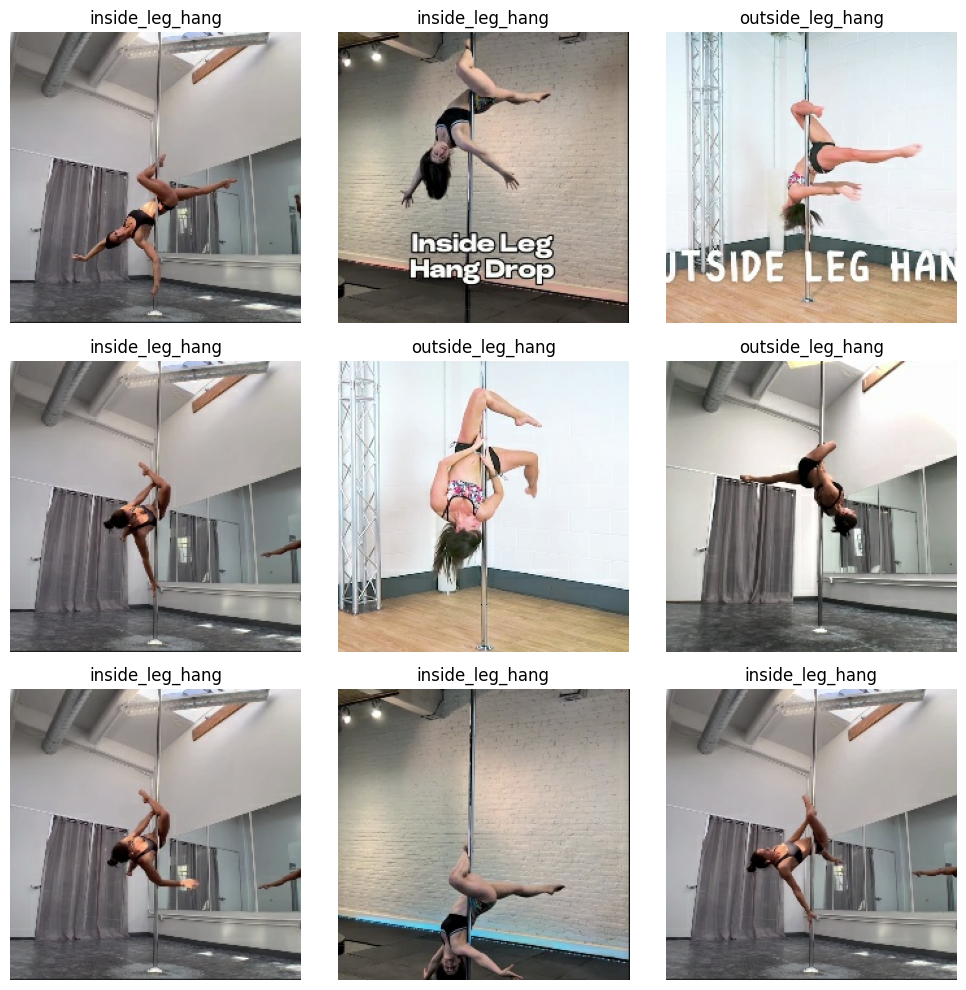

In [44]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    n = min(9, int(images.shape[0]))
    for i in range(n):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(images[i]).astype("uint8"))
        lbl = int(labels[i])
        title = class_names[lbl] if lbl < len(class_names) else str(lbl)
        plt.title(title)
        plt.axis("off")
plt.tight_layout()
plt.show()

# Train baseline model - EfficientNetB0

In [51]:
# 1. Load the base model with pre-trained ImageNet weights
# include_top=False removes the final 1000-class layer
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# 2. Freeze the base model (don't train its internal weights yet)
base_model.trainable = False

# 3. Add custom layers for your specific task (e.g., 2 classes: Cats vs. Dogs)
x = GlobalAveragePooling2D()(base_model.output)
x = Dropout(0.5)(x)  # Higher dropout rate to prevent overfitting
output = Dense(2, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# 4. Compile
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), loss='sparse_categorical_crossentropy', metrics=['accuracy'])



Basic model overfits since dataset is too small.

In [52]:
# Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10  # Start with 10 for transfer learning
)

Epoch 1/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 13s 222ms/step - accuracy: 0.6170 - loss: 0.6585 - val_accuracy: 0.9105 - val_loss: 0.5183
Epoch 2/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 9s 198ms/step - accuracy: 0.7418 - loss: 0.5364 - val_accuracy: 0.9895 - val_loss: 0.4142
Epoch 3/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 10s 203ms/step - accuracy: 0.8384 - loss: 0.4450 - val_accuracy: 1.0000 - val_loss: 0.3359
Epoch 4/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 10s 207ms/step - accuracy: 0.9014 - loss: 0.3630 - val_accuracy: 1.0000 - val_loss: 0.2771
Epoch 5/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 10s 209ms/step - accuracy: 0.9376 - loss: 0.3108 - val_accuracy: 1.0000 - val_loss: 0.2321
Epoch 6/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 10s 211ms/step - accuracy: 0.9415 - loss: 0.2784 - val_accuracy: 1.0000 - val_loss: 0.1964
Epoch 7/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 10s 212ms/step - accuracy: 0.9717 - loss: 0.2346 - val_accuracy: 1.0000 - val_loss: 0.1687
Epoch 8/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 10s 217ms/step - accuracy: 0.9737 - loss: 0.2105 - val_accur

In [53]:
# 1. Get images and labels from validation set
val_images, val_labels = next(iter(val_ds.unbatch().batch(100))) # Take 100 samples
preds = model.predict(val_images)
pred_labels = (preds > 0.5).astype(int).flatten()
true_labels = val_labels.numpy().flatten()

# 2. Find indices where prediction != truth
misclassified_indices = np.where(pred_labels != true_labels)[0]

# 3. Plot the first 9 errors
plt.figure(figsize=(10, 10))
for i, idx in enumerate(misclassified_indices[:9]):
    plt.subplot(3, 3, i + 1)
    plt.imshow(val_images[idx].numpy().astype("uint8"))
    plt.title(f"True: {true_labels[idx]} | Pred: {pred_labels[idx]}")
    plt.axis("off")

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 314ms/step


ValueError: operands could not be broadcast together with shapes (200,) (100,) 